# TP 1 Inferencia y Estimación
### Bivona, Catania y Fenley

In [3]:
#Imports de librerias
import numpy as np
import pandas as pd
from PIL import Image
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import random


# Ejercicio 1: (quizas despues algun subtitulo o algo)

In [4]:
#Cargamos las imágenes

ruta_dataset = 'dataset_tp1'

ruta_train = ruta_dataset + '/train'
ruta_test = ruta_dataset + '/test'

ruta_train_labels = ruta_dataset + '/train_labels.csv'
ruta_test_labels = ruta_dataset + '/test_labels.csv'

train_labels = pd.read_csv(ruta_train_labels)
test_labels = pd.read_csv(ruta_test_labels)

X_train = []
y_train = []
X_test = []
y_test = []
i=0 ##Para que es??

for _, fila in train_labels.iterrows():
    nombre = fila['archivo']
    clase = fila['clase']

    ruta = os.path.join(ruta_train, nombre)

    img = Image.open(ruta).convert('L')
    X_train.append(np.array(img))
    y_train.append(clase)

for _, fila in test_labels.iterrows():
    nombre = fila['archivo']
    clase = fila['clase']

    ruta = os.path.join(ruta_test, nombre)

    img = Image.open(ruta).convert('L')
    X_test.append(np.array(img))
    y_test.append(clase)


X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)


#Convertimos cada imagen sea un vector
X_train_vec = X_train.reshape(X_train.shape[0], -1)
X_test_vec = X_test.reshape(X_test.shape[0], -1)

### Inciso a

In [5]:
#CASO FOTOS NORMALES
#Creamos el modelo y lo entrenamos con el vector de las imágenes train
lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train_vec, y_train)

#Testeo
y_testeado = lr_model.predict(X_test_vec)

# Calculamos y mostramos el accuracy del modelo
acc = accuracy_score(y_test, y_testeado)

print("Accuracy:", acc)

Accuracy: 0.8183760683760684


### Inciso b

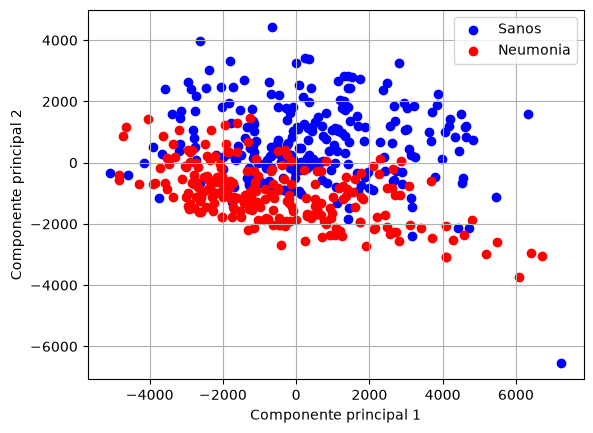

In [6]:
#CASOS PCA MEDIANTE SVD CON DISTINTOS K
#Restamos la esperanza a X_train y X_test para centrarlos
media_train = np.mean(X_train_vec, axis=0)
X_train_centrado = X_train_vec - media_train
media_test = np.mean(X_test_vec, axis=0)
##Buscando para el dos me dice que reste media train, despues podría preguntar (voy a probar como queda)
#X_test_centrado = X_test_vec - media_test
X_test_centrado=X_test_vec-media_train
#Aplicamos SVD
U, S, Vt = np.linalg.svd(X_train_centrado, full_matrices=False)

#Definimos una funcion que utiliza X_train para crear la matriz de proyeccion y dado un k proyecta x_test en el espacio de k componentes principales
def proyectar_componentes_principales(k):
    Vk=Vt[:k].T
    proyeccion=X_test_centrado@Vk
    return proyeccion
#Usamos la funcion para proyectar X_test en el espaxio de las dos primeras componentes principales
proyeccion_k_2=proyectar_componentes_principales(2)

#Graficamos el resultado de la proyeccion asignandole colores (segun la clase a la que verdaderamente pertenecen)
plt.figure()
#Obtenemos los indices que pertenecen a cada clase
sanos=y_test==0
neumonia=y_test==1

plt.grid()
#Azul son los sanos y rojos los que tienen neumonia
plt.scatter(proyeccion_k_2[sanos,0],proyeccion_k_2[sanos,1],color="blue",label="Sanos")
plt.scatter(proyeccion_k_2[neumonia,0],proyeccion_k_2[neumonia,1],color="red",label="Neumonia")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.show()

### Inciso c:

c:\Users\Cristina\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 13882 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


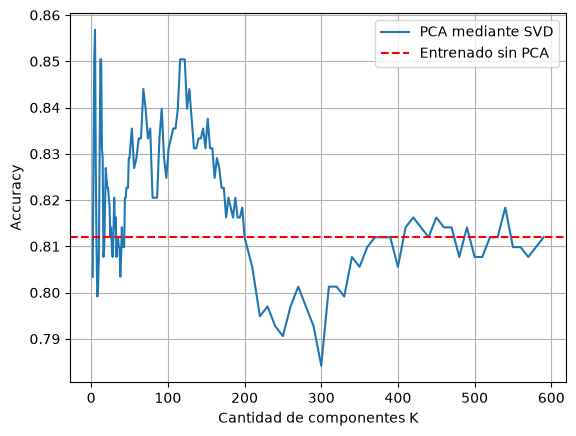

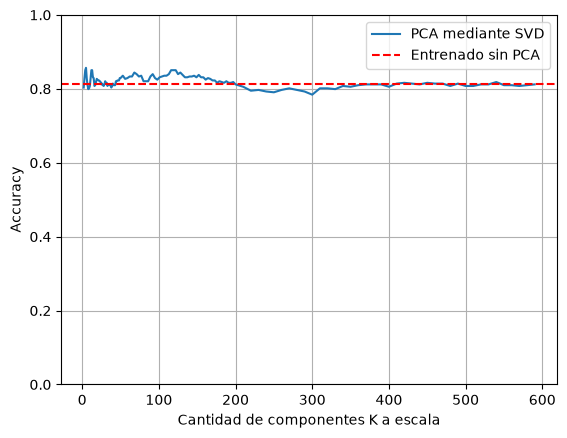

In [19]:
#Comenzamos a iterar sobre los distintos valores posibles de k
accuracies = []
valores_k = list(range(2, 51)) + list(range(53, 201, 3)) + list(range(210, 600, 10))

for K in valores_k:
    #Tomamos las primeras K componentes
    Vk = Vt[:K].T

    #Proyectamos train y test en el espacio de k componentes principales
    Z_train = X_train_centrado @ Vk     
    Z_test = X_test_centrado @ Vk       

    #entrenamos el modelo con el PCA aplicado a los datos de train
    lr_model = LogisticRegression(max_iter=20000)    
    lr_model.fit(Z_train, y_train)

    #Testeamos el modelo y obtenemos su accuracy 
    y_testeado_k = lr_model.predict(Z_test)     
    acc = accuracy_score(y_test, y_testeado_k)      
    accuracies.append(acc)


#Graficamos como varia el accuracy (el desempeño) en funcion de los k
plt.figure()
plt.grid()
plt.plot(valores_k, accuracies, label="PCA mediante SVD")

#Graficamos el accuracy que nos habia dado para el modelo entrenado sin el PCA aplicado
plt.axhline(
    acc,
    linestyle="--",
    label="Entrenado sin PCA",
    color="red"
)

plt.xlabel("Cantidad de componentes K")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


plt.figure()
plt.grid()
plt.plot(valores_k, accuracies, label="PCA mediante SVD")

#Graficamos el accuracy que nos habia dado para el modelo entrenado sin el PCA aplicado
plt.axhline(
    acc,
    linestyle="--",
    label="Entrenado sin PCA",
    color="red"
)

plt.xlabel("Cantidad de componentes K a escala")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.show()

# Ejercicio 2:
### Todos los incisos

In [6]:
#Proyectamos train y test en el espacio de las dos componentes principales 
V2=Vt[:2].T
Z_train = X_train_centrado @ V2     
Z_test = X_test_centrado @ V2 
#Entrenamos el modelo y calculamos su accuracy     
lr_model = LogisticRegression(max_iter=2000)    
lr_model.fit(Z_train, y_train)
y_testeado_2 = lr_model.predict(Z_test)  
a0 = accuracy_score(y_test, y_testeado_2) 

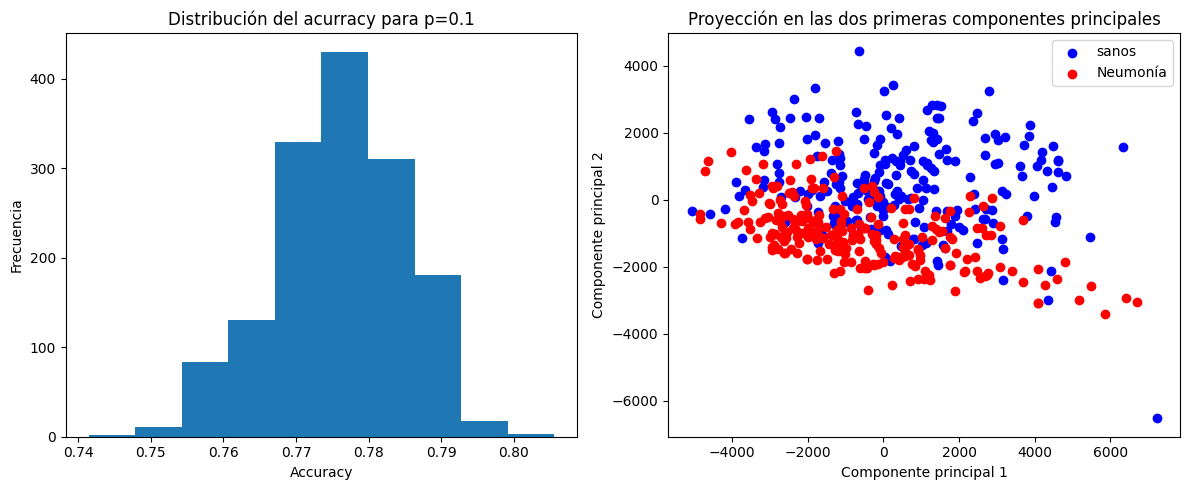

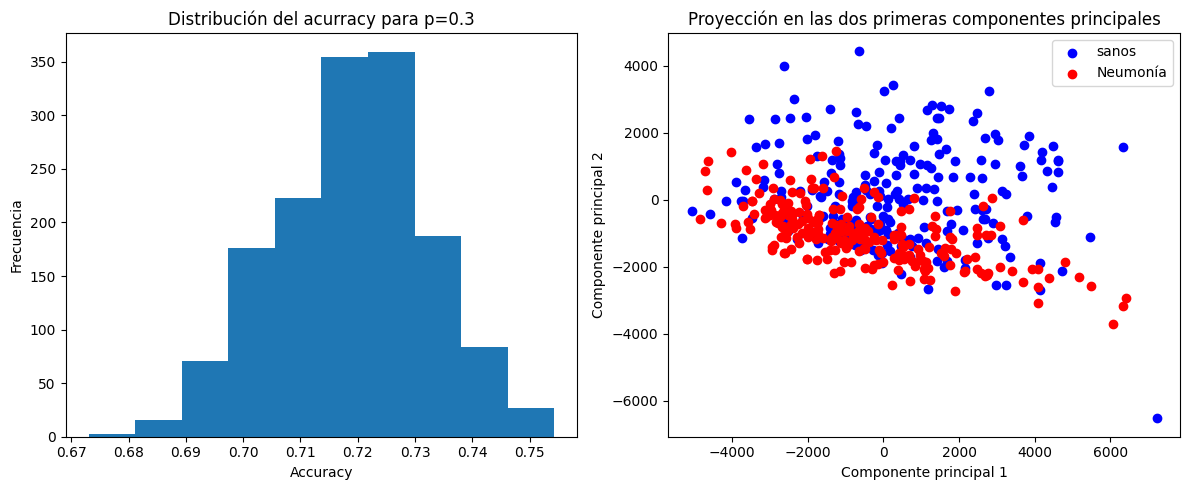

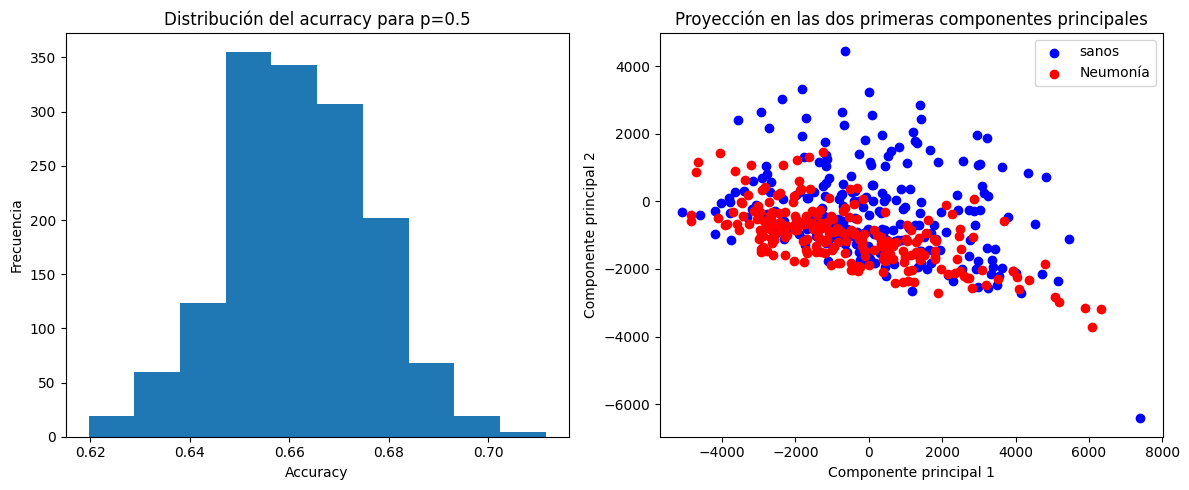

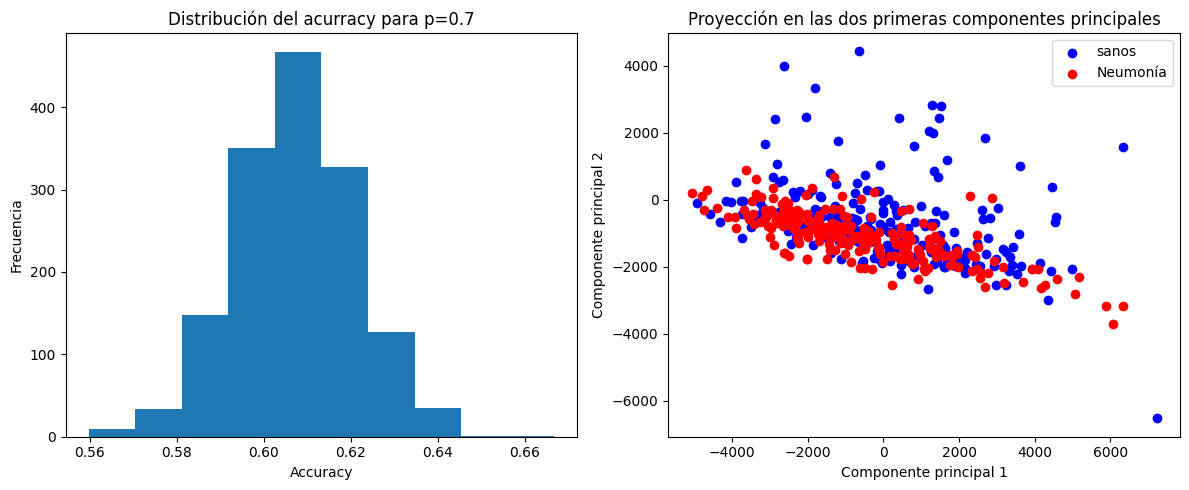

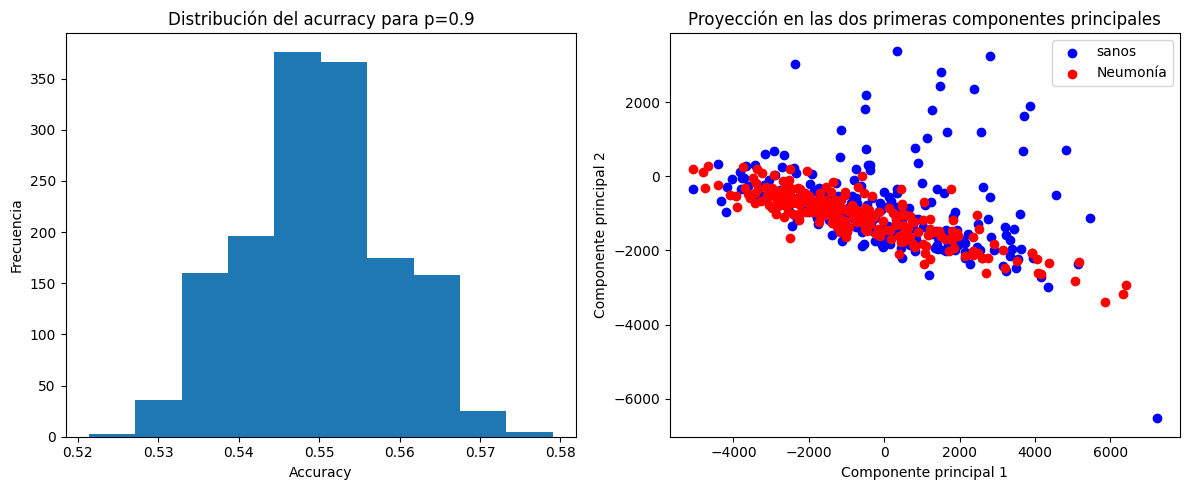

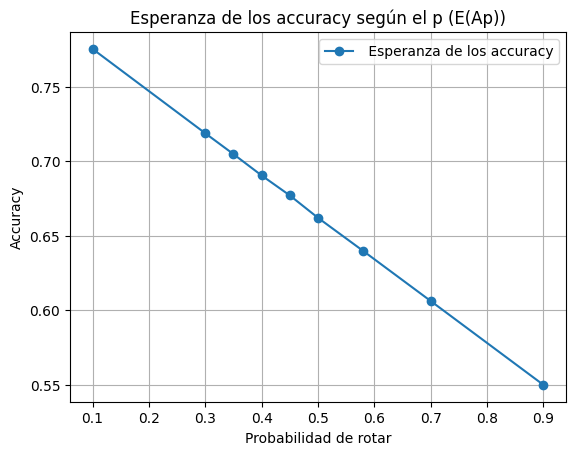

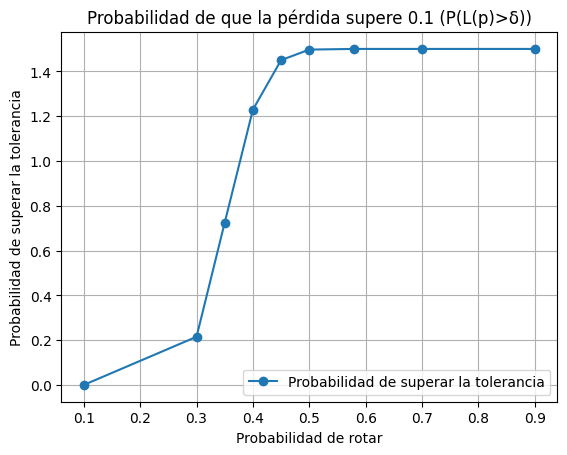

In [ ]:
#Para graficar el scatter de las dos componentes principales dada la proyeccion
def scatter_2_comp_princip (Z,ax):
    #Usamos ax para que este grafico y el del histograma aoarezcan juntos (uno al lado del otro)
    ax.scatter(Z[sanos,0],Z[sanos,1],color="blue",label="sanos")
    ax.scatter(Z[neumonia,0],Z[neumonia,1],color="red",label="Neumonía")#FALTARIA PONERLE QUIZAS ALGUN TITULO
    ax.set_xlabel("Componente principal 1")
    ax.set_ylabel("Componente principal 2")
    ax.set_title(f"Proyección en las dos primeras componentes principales")
    ax.legend()
#Definimos una funcion que con probabilidad p rota las imagenes del conjunto de test y luego, al conjunto entero,
#lo proyecta en el espacio de las dos componentes principales y lo evalúa con el modelo para luego obtener su accuracy
def evaluacion_imagenes_rotadas(p,mostrar=0,ax=None):
    x_test_rotado=X_test_vec.copy()

    for i  in range(len(X_test_vec)):
        if(random.random()<=p):
            x_test_rotado[i]=x_test_rotado[i][::-1]
    Z_test_rotado=(x_test_rotado-media_train)@V2
    #Si se pide se hace un scatter de las ods componentes principales
    if(mostrar):
        scatter_2_comp_princip(Z_test_rotado,ax)
    y_rotado_testeado=lr_model.predict(Z_test_rotado)
    ap=accuracy_score(y_test,y_rotado_testeado)
    return ap

#quizas pueda sacar despues algunos p, los puse más que nada para que quede menos tosco los ultimos dos gráficos
#Despues podria hacerlo en una funcion y generalizar ( en vez de 100 un numero ajustable y poder ajustar la tolerancia, etc)

#Definimos las probabilidades para las cuales vamos a hacer el experimento
p_evaluar=[0.1,0.3,0.35,0.4,0.45,0.5,0.58,0.7,0.9]
#Definimos algunos valores de p para graficar el histograma y el scatter
p_graficar=[0.1,0.3,0.5,0.7,0.9] 
esperanza_acc=[]
prob_superar_tol=[]
#Por cada p hacemos 1000 simulaciones de rotar las imagenes con probabilidad p calcular el accuracy y la diferencia con el calculado sin PCA
for p in p_evaluar:
    accuracy_img_rotadas=[]
    diferencias_a0_ap=[]
    if p in p_graficar:
        fig,ax=plt.subplots(1,2,figsize=(12,5))
    for i in range(1500):
        #Solo se grafica el scatter si es la primera iteración
        ap=evaluacion_imagenes_rotadas(p,i==0 and p in p_graficar,ax[1])
        accuracy_img_rotadas.append(ap)
        diferencias_a0_ap.append(a0-ap)
    #Graficamos el histograma que se pone al lado del scatter
    if p in p_graficar:
        ax[0].hist(accuracy_img_rotadas)
        ax[0].set_ylabel("Frecuencia")
        ax[0].set_xlabel("Accuracy")
        ax[0].set_title(f"Distribución del acurracy para p={p}")
        #Esto es para que ajuste las distancias y no se superpongan los subtitulos de los ejes ni nada (para que se vea bien)
        fig.tight_layout()
        plt.show()
    #Agregamos los resultados obtenidos para luego poder graficar
    esperanza_acc.append(np.mean(accuracy_img_rotadas))
    prob_superar_tol.append(np.sum(np.array(diferencias_a0_ap)>0.1)/1000)

#Realizamos dos graficos
#Graficamos la esperanza del accuracy dependiendo de la probabilidad de rotar
plt.figure()
plt.title("Esperanza de los accuracy según el p (E(Ap))")
plt.grid()
plt.plot(p_evaluar, esperanza_acc, marker="o",label=" Esperanza de los accuracy")
plt.xlabel("Probabilidad de rotar")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#Graficamos la probabilidad de que la diferencia entre accuracys (el calculado sin PCA y el con PCA) supere una cierta tolerancia (0.1)
plt.figure()
plt.title("Probabilidad de que la pérdida supere 0.1 (P(L(p)>δ))")
plt.grid()
plt.plot(p_evaluar,prob_superar_tol, marker="o",label="Probabilidad de superar la tolerancia")
plt.xlabel("Probabilidad de rotar")
plt.ylabel("Probabilidad de superar la tolerancia")
plt.legend()
plt.show()

